In [1]:
#undef __noinline__

# Generating a Fractal (The Julia Set)

We are using CUDA to draw a complex mathematical shape called a Julia Set. It applies the same formula and colors each pixel based on the value. The formula used for this example is:$$Z_{n+1} = Z_n^2 + C$$ Instead of calculating pixels one by one on the CPU, we launch a kernel where each GPU thread calculates the color of a single pixel simultaneously. How it works **cuComplex** A helper to do math with complex numbers ($a + bi$).julia: The math logic. It checks if a point "escapes" to infinity or stays trapped in the set.julia_kernel: The GPU function that tells each pixel: "If you're in the set, turn Red ($255$); if not, stay Black ($0$)."

In [2]:
#include <cuda_runtime.h>
#include <iostream>

#define DIM 1000

// A minimal complex number type usable on both CPU and GPU
struct Complex {
    float re, im;

    __host__ __device__ Complex(float a, float b) : re(a), im(b) {}

    __device__ float magnitude_squared() {
        return re * re + im * im;
    }

    __device__ Complex operator*(const Complex &o) {
        return Complex(re * o.re - im * o.im,
                       im * o.re + re * o.im);
    }

    __device__ Complex operator+(const Complex &o) {
        return Complex(re + o.re, im + o.im);
    }
};

In [3]:
__device__ int julia_kernel_logic(int px, int py) {
    const float scale = 1.5f;
    float z_re = scale * (float)(DIM / 2 - px) / (DIM / 2);
    float z_im = scale * (float)(DIM / 2 - py) / (DIM / 2);

    Complex z(z_re, z_im);
    Complex c(-0.8f, 0.156f);   // The constant C that defines this particular Julia set

    for (int iter = 0; iter < 200; iter++) {
        z = z * z + c;
        if (z.magnitude_squared() > 1000.0f)
            return 0;   // Escaped — not in the set
    }
    return 1;           // Stayed bounded — in the set
}

__global__ void julia_kernel(unsigned char *ptr, int w, int h) {
    int x = blockIdx.x;
    int y = blockIdx.y;

    if (x >= w || y >= h) return;

    int offset = x + y * w;
    int in_set = julia_kernel_logic(x, y);

    // Write RGBA values to the image buffer
    if (in_set) {
        ptr[offset * 4 + 0] = 255; // R
        ptr[offset * 4 + 1] = 255; // G
        ptr[offset * 4 + 2] = 255; // B
        ptr[offset * 4 + 3] = 255; // A
    } else {
        ptr[offset * 4 + 0] = 0;   // R
        ptr[offset * 4 + 1] = 0;   // G
        ptr[offset * 4 + 2] = 0;   // B
        ptr[offset * 4 + 3] = 255; // A
    }
}

Here we call the kernel and write the data to a .png file

In [4]:
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "headers/stb_image_write.h"

unsigned char *pixels;
cudaMallocManaged(&pixels, DIM * DIM * 4);

dim3 grid(DIM, DIM);
julia_kernel<<<grid, 1>>>(pixels, DIM, DIM);
cudaDeviceSynchronize();

stbi_write_png("images/julia.png", DIM, DIM, 4, pixels, DIM * 4);
std::cout << "Saved julia.png" << std::endl;

cudaFree(pixels);

Saved julia.png


And now we display the result:

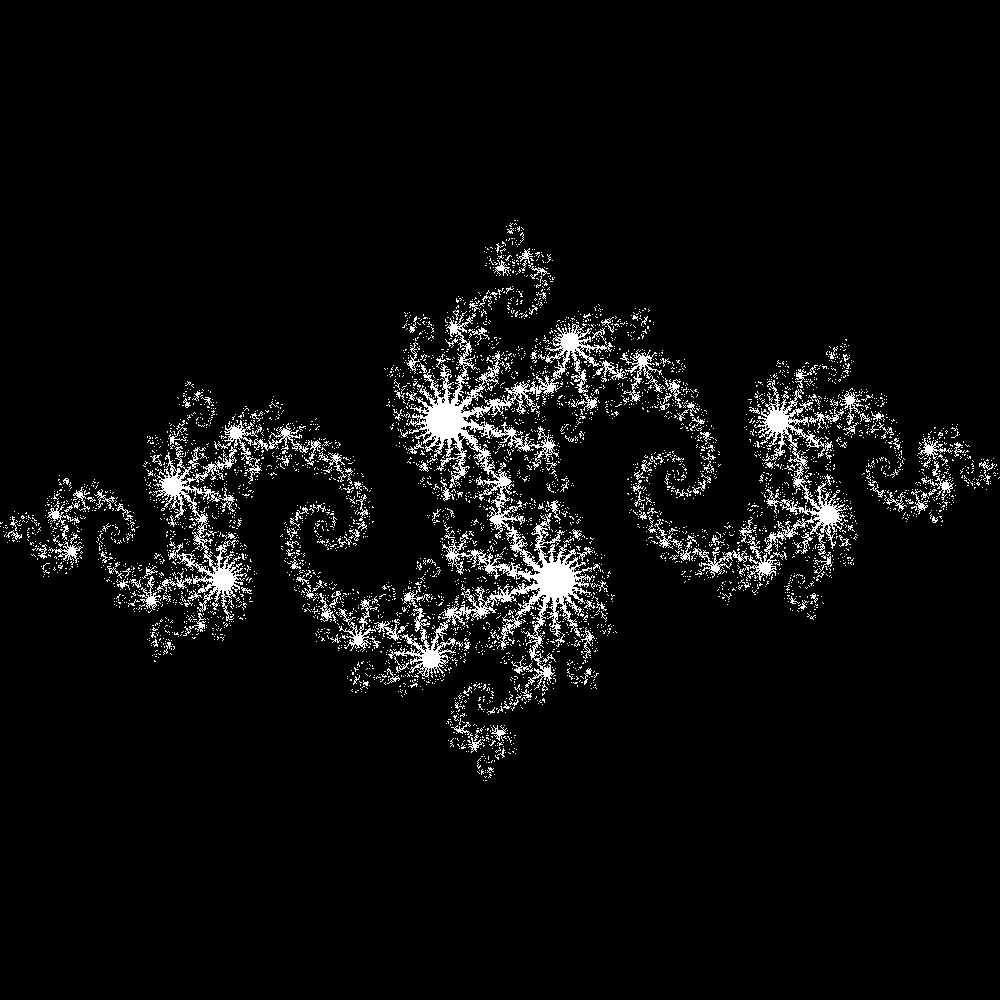

In [5]:
#include "headers/display.hpp"

im::image julia_image("images/julia.png");
xcpp::display(julia_image);